In [1]:
# use holodeck environment

In [1]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [14]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

import corner
from matplotlib.lines import Line2D

## MCMC using GPs and NNs (figure 7)

updated GP chain length: (274100, 6)
updated NN chain length: (512000, 6)


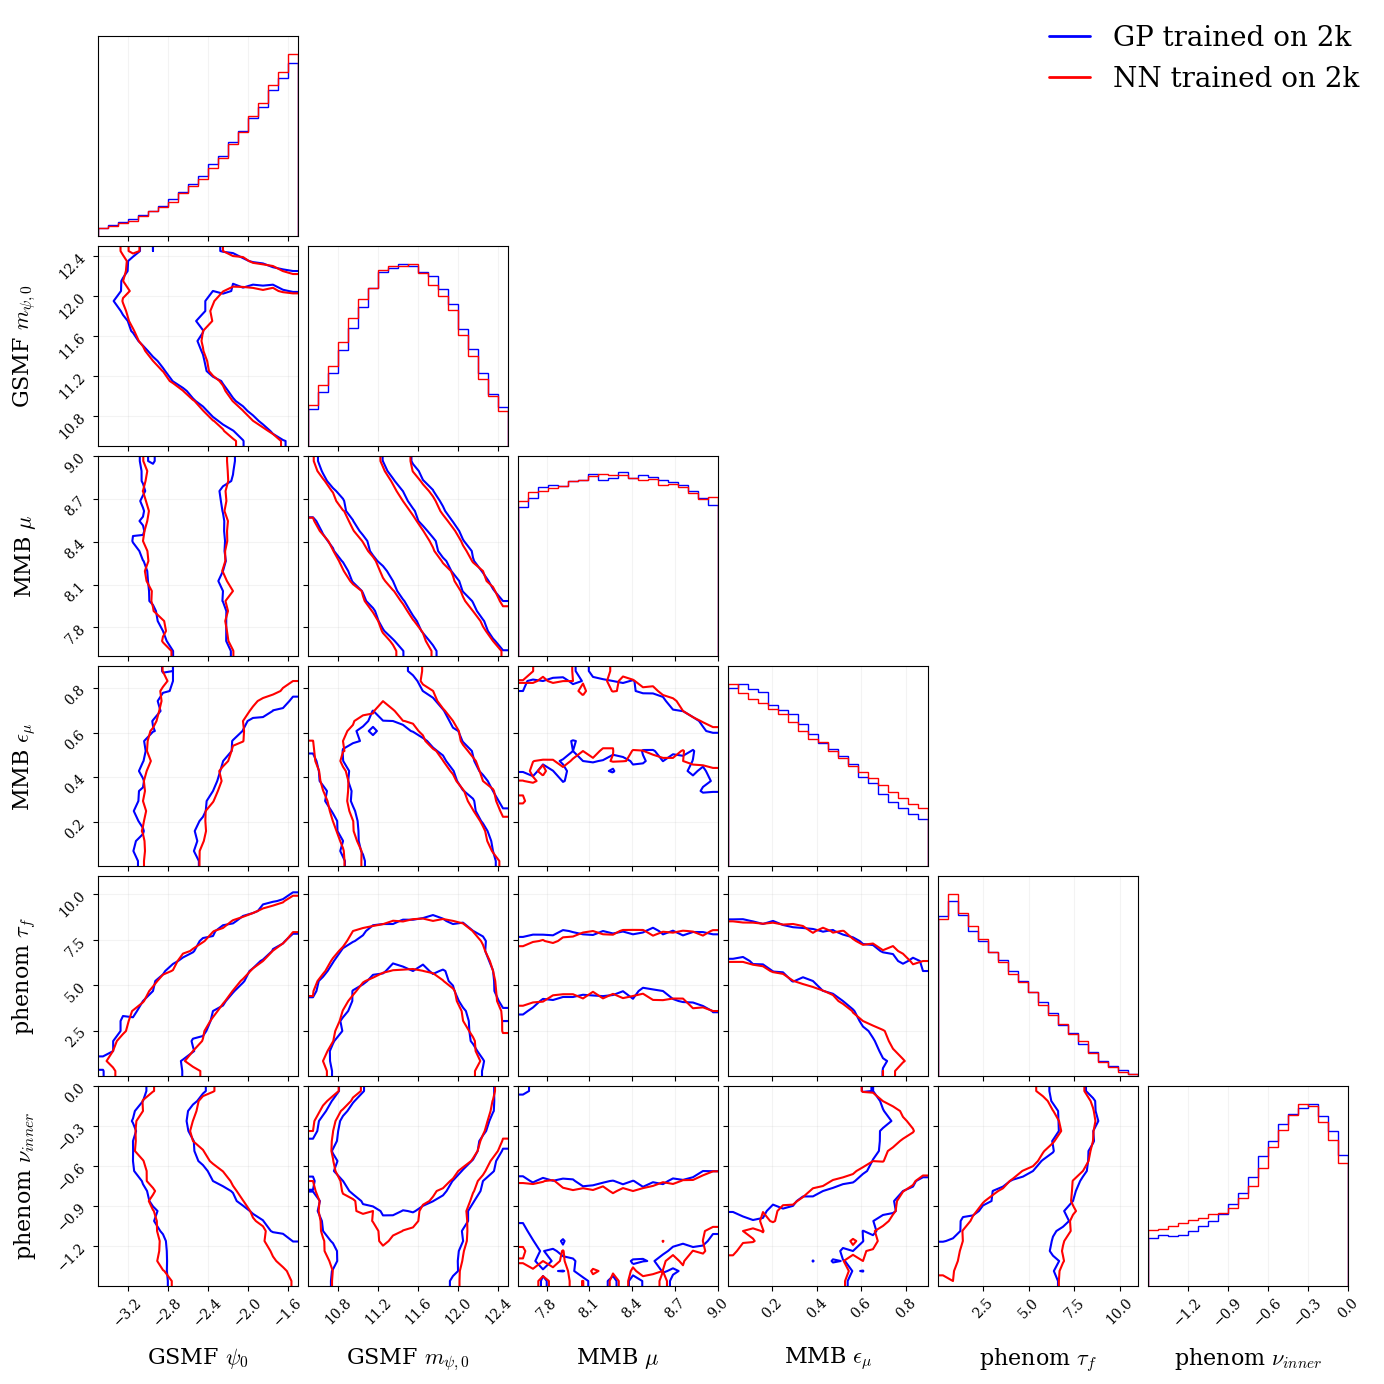

In [ ]:
# mcmc using GP
chain_path_gp = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/gp_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
data_gp = np.loadtxt(chain_path_gp)

# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - hard_time
# index 5 - hard_gamma_inner

# corner with selected params
data_copy_gp = data_gp
data_copy_gp = data_copy_gp[:, [0, 1, 2, 3, 4, 5]]

print(f'updated GP chain length: {data_copy_gp.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

# mcmc using NN
chain_path_nn = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/nn_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
data_nn = np.loadtxt(chain_path_nn)
data_copy_nn = data_nn
data_copy_nn = data_copy_nn[:, [0, 1, 2, 3, 4, 5]]
print(f'updated NN chain length: {data_copy_nn.shape}')

labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"phenom $\tau_f$", r"phenom $\nu_{inner}$"]


# ranges for astro params as seen in fig 10 of agazie2023
ranges = [(-3.5, -1.5), (10.5, 12.5), (7.6, 9), (0, 0.9), (0, 11), (-1.5, 0)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)

# Generate the corner plot with partial limits
fig = corner.corner(
    data_copy_gp,
    labels=labels,
    show_titles=False, # to turn off the reporting of median and 1 sigma values
    plot_density=False,
    plot_contours=True,
    fill_contours=False,  # This makes the contour regions filled with color
    # levels=[0.68, 0.95, 0.997],  # Confidence levels
    levels=[0.68, 0.95],  # Confidence levels
    plot_datapoints=False,      # ← turn off the scatter
    color='blue',
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16, "loc": "left"},
    # fig=plt.figure(figsize=(6, 6)),
    range=ranges,  # Apply limits only to the first two
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)

# Generate the corner plot with partial limits
corner.corner(
    data_copy_nn,
    fig=fig,
    labels=labels,
    show_titles=False,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,  # This makes the contour regions filled with color
    # levels=[0.68, 0.95, 0.997],  # Confidence levels
    levels=[0.68, 0.95],  # Confidence levels
    plot_datapoints=False,      # ← turn off the scatter
    color='red',
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16, "loc": "left"},
    # fig=plt.figure(figsize=(6, 6)),
    range=ranges,  # Apply limits only to the first two
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)


legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=f'GP trained on 2k'),
    Line2D([0], [0], color='red', lw=2, label=f'NN trained on 2k')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()


In [31]:
# median values table

def summary_stats(chain):
    median = np.median(chain, axis=0)
    p16 = np.percentile(chain, 16, axis=0)
    p84 = np.percentile(chain, 84, axis=0)
    return median, p16, p84

med_gp, p16_gp, p84_gp = summary_stats(data_copy_gp)
med_nn, p16_nn, p84_nn = summary_stats(data_copy_nn)

labels = [
    r"GSMF $\psi_0$",
    r"GSMF $m_{\psi, 0}$",
    r"MMB $\mu$",
    r"MMB $\epsilon_{\mu}$",
    r"phenom $\tau_f$",
    r"phenom $\nu_{inner}$"
]

print(f"{'Parameter':<25} {'GP':>25} {'NN':>25}")
print("-"*80)

for i, name in enumerate(labels):
    gp_plus  = p84_gp[i] - med_gp[i]
    gp_minus = med_gp[i] - p16_gp[i]
    
    nn_plus  = p84_nn[i] - med_nn[i]
    nn_minus = med_nn[i] - p16_nn[i]
    
    gp_str = f"{med_gp[i]:.2f} (+{gp_plus:.2f}, -{gp_minus:.2f})"
    nn_str = f"{med_nn[i]:.2f} (+{nn_plus:.2f}, -{nn_minus:.2f})"
    
    print(f"{name:<25} {gp_str:>25} {nn_str:>25}")

Parameter                                        GP                        NN
--------------------------------------------------------------------------------
GSMF $\psi_0$                  -1.98 (+0.34, -0.59)      -1.96 (+0.33, -0.59)
GSMF $m_{\psi, 0}$             11.50 (+0.50, -0.49)      11.47 (+0.50, -0.49)
MMB $\mu$                       8.30 (+0.46, -0.46)       8.30 (+0.46, -0.46)
MMB $\epsilon_{\mu}$            0.32 (+0.31, -0.22)       0.33 (+0.33, -0.23)
phenom $\tau_f$                 2.89 (+3.05, -2.04)       2.84 (+3.07, -1.99)
phenom $\nu_{inner}$           -0.49 (+0.31, -0.52)      -0.50 (+0.32, -0.57)


In [36]:
# print latex code for the table
def latex_table_compare(labels, med_gp, p16_gp, p84_gp,
                       med_nn, p16_nn, p84_nn,
                       caption="Phenomenological model parameter constraints from MCMCs using: GP vs NN",
                       label="tab:phenom_posterior_median"):
    
    lines = []
    lines.append(r"\begin{table}")
    lines.append(r"\centering")
    lines.append(r"\renewcommand{\arraystretch}{1.6}")
    lines.append(r"\begin{tabular}{|l|r|r|}")
    lines.append(r"\hline")
    lines.append(r"Parameter & GP & NN \\")
    lines.append(r"\hline")
    
    for i, name in enumerate(labels):
        gp_plus  = p84_gp[i] - med_gp[i]
        gp_minus = med_gp[i] - p16_gp[i]
        
        nn_plus  = p84_nn[i] - med_nn[i]
        nn_minus = med_nn[i] - p16_nn[i]
        
        gp_str = f"${med_gp[i]:.2f}^{{+{gp_plus:.2f}}}_{{-{gp_minus:.2f}}}$"
        nn_str = f"${med_nn[i]:.2f}^{{+{nn_plus:.2f}}}_{{-{nn_minus:.2f}}}$"
        
        lines.append(f"{name} & {gp_str} & {nn_str} \\\\")
    
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

latex_code = latex_table_compare(
    labels,
    med_gp, p16_gp, p84_gp,
    med_nn, p16_nn, p84_nn
)

print(latex_code)

\begin{table}
\centering
\renewcommand{\arraystretch}{1.6}
\begin{tabular}{|l|r|r|}
\hline
Parameter & GP & NN \\
\hline
GSMF $\psi_0$ & $-1.98^{+0.34}_{-0.59}$ & $-1.96^{+0.33}_{-0.59}$ \\
GSMF $m_{\psi, 0}$ & $11.50^{+0.50}_{-0.49}$ & $11.47^{+0.50}_{-0.49}$ \\
MMB $\mu$ & $8.30^{+0.46}_{-0.46}$ & $8.30^{+0.46}_{-0.46}$ \\
MMB $\epsilon_{\mu}$ & $0.32^{+0.31}_{-0.22}$ & $0.33^{+0.33}_{-0.23}$ \\
phenom $\tau_f$ & $2.89^{+3.05}_{-2.04}$ & $2.84^{+3.07}_{-1.99}$ \\
phenom $\nu_{inner}$ & $-0.49^{+0.31}_{-0.52}$ & $-0.50^{+0.32}_{-0.57}$ \\
\hline
\end{tabular}
\caption{Phenomenological model parameter constraints from MCMCs using: GP vs NN}
\label{tab:phenom_posterior_median}
\end{table}
